# FEEDS — Red Deer FB: Correlation & Feature Importance
**Goal:** Validate that the same economic drivers found in the AFB model (NLDB, AISH, CPI Food)
also explain Red Deer hamper demand — establishing generalizability across food bank organizations.

Sections:
1. Install & imports
2. Upload cleaned datasets + external features
3. Merge & align
4. Exploratory: long-run trend + pounds-per-hamper
5. Correlation analysis (vs AFB findings)
6. XGBoost feature importance + SHAP
7. Supply-side: donor dependency & AFB→RDFB link
8. Summary of findings

Three of the five strongest demand predictors at the provincial level — CPI Food, Edmonton AISH caseload, and CPI Shelter — also ranked in the top five predictors of regional hamper demand, suggesting that economic cost-of-living pressures drive food insecurity consistently across organizational scales.

## 1. Install & imports

In [1]:
!pip install shap xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import xgboost as xgb
import shap

# ── Colour palette (matches FeedForward brand) ─────────────────────────────────
C = {
    "green":  "#224433",
    "teal":   "#3f826d",
    "tea":    "#d0efb1",
    "denim":  "#5588c7",
    "gold":   "#e1dd8f",
    "red":    "#c0622a",
    "bg":     "#fbfcf6",
}

plt.rcParams.update({
    "figure.facecolor": C["bg"],
    "axes.facecolor":   C["bg"],
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.family":      "sans-serif",
})

print("All imports OK")

All imports OK


## 2. Upload cleaned datasets + external features

In [3]:
from google.colab import files

# ── 2a. Hamper count (2011–2026) ───────────────────────────────────────────────
print("Upload rdfb_hamper_monthly.csv ...")
up1 = files.upload()
df_hamper = pd.read_csv(list(up1.keys())[0], parse_dates=["month"])
print(f"  Hamper: {df_hamper.shape[0]} rows | {df_hamper['month'].min().date()} → {df_hamper['month'].max().date()}")

# ── 2b. Donation / supply (2025–2026) ─────────────────────────────────────────
print("Upload rdfb_donations_monthly.csv (or monthly_summary.csv) ...")
up2 = files.upload()
df_donations = pd.read_csv(list(up2.keys())[0], parse_dates=["month"])
print(f"  Donations: {df_donations.shape[0]} rows | {df_donations['month'].min().date()} → {df_donations['month'].max().date()}")

# ── 2c. External feature dataset (same CSV used in AFB model) ─────────────────
print("Upload your external feature CSV (the one used for AFB regressors) ...")
up3 = files.upload()
df_ext_raw = pd.read_csv(list(up3.keys())[0])
print(f"  External features: {df_ext_raw.shape}")
print(f"  Columns: {list(df_ext_raw.columns)}")

Upload rdfb_hamper_monthly.csv ...


Saving hamper_count_clean.csv to hamper_count_clean.csv
  Hamper: 185 rows | 2011-01-01 → 2026-05-01
Upload rdfb_donations_monthly.csv (or monthly_summary.csv) ...


Saving monthly_summary.csv to monthly_summary.csv
  Donations: 17 rows | 2025-01-01 → 2026-05-01
Upload your external feature CSV (the one used for AFB regressors) ...


Saving data.csv to data.csv
  External features: (1977, 23)
  Columns: ['Date', 'Month', 'holiday_is_stat', 'holiday_is_religious', 'holiday_is_cultural', 'is_holiday', 'is_covid', 'School_In_Session', 'CCB_Dates', 'Exam_Period', 'International_Arrival', 'NLDB', 'CPP', 'OAS', 'CPI All-items', 'CPI Food', 'CPI Shelter', 'Net Migration', 'AISH_TOTAL', 'SINGLE_AISH_TOTAL', 'SINGLE_AISH_PARENT', 'EDMONTON_AISH_CASELOAD', 'Max Temp (°C)']


## 3. Merge & align on month

In [4]:
# ── Standardise date column in external features ───────────────────────────────
# Adjust 'Date' to match whatever your column is named
DATE_COL = "Date"   # ← change if your column is named differently

df_ext = df_ext_raw.copy()
df_ext[DATE_COL] = pd.to_datetime(df_ext[DATE_COL])
df_ext["month"]  = df_ext[DATE_COL].dt.to_period("M").dt.to_timestamp()

# If daily data: aggregate to monthly mean
if df_ext.groupby("month").size().max() > 3:
    numeric_cols = df_ext.select_dtypes(include="number").columns.tolist()
    df_ext = df_ext.groupby("month")[numeric_cols].mean().reset_index()

# ── AFB regressors (same 16 used in your model) ───────────────────────────────
AFB_REGRESSORS = [
    "NLDB", "EDMONTON_AISH_CASELOAD", "CPI Food",
    "SINGLE_AISH_TOTAL", "CPI All-items", "CPI Shelter",
    "SINGLE_AISH_PARENT", "AISH_TOTAL", "holiday_is_cultural",
    "Exam_Period", "CDB", "International_Arrival", "is_covid",
    "School_In_Session", "holiday_is_religious", "holiday_is_stat",
]
# Keep only those that exist in the external file
REGRESSORS = [r for r in AFB_REGRESSORS if r in df_ext.columns]
print(f"Regressors found in external file: {len(REGRESSORS)} / {len(AFB_REGRESSORS)}")
missing = [r for r in AFB_REGRESSORS if r not in df_ext.columns]
if missing:
    print(f"  Missing (will be skipped): {missing}")

# ── Merge hamper + external features ──────────────────────────────────────────
df = df_hamper.merge(df_ext[["month"] + REGRESSORS], on="month", how="left")

# ── Merge donations where available ───────────────────────────────────────────
df = df.merge(df_donations, on="month", how="left")

# ── Fix AISH comma strings if needed ──────────────────────────────────────────
for col in ["AISH_TOTAL", "SINGLE_AISH_TOTAL", "EDMONTON_AISH_CASELOAD", "SINGLE_AISH_PARENT"]:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ""), errors="coerce"
        )

# ── Scale regressors (match AFB preprocessing) ────────────────────────────────
scaler = StandardScaler()
REGRESSORS_PRESENT = [r for r in REGRESSORS if df[r].notna().sum() > 10]
df[REGRESSORS_PRESENT] = scaler.fit_transform(df[REGRESSORS_PRESENT].fillna(0))

print(f"\nMerged dataset: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"Date range    : {df['month'].min().date()} → {df['month'].max().date()}")
print(f"External features available for {df[REGRESSORS_PRESENT[0]].notna().sum()} months")
df.tail(4)

Regressors found in external file: 15 / 16
  Missing (will be skipped): ['CDB']

Merged dataset: 185 rows x 33 cols
Date range    : 2011-01-01 → 2026-05-01
External features available for 185 months


,month,hampers,adults,children,families,total_people,NLDB,EDMONTON_AISH_CASELOAD,CPI Food,SINGLE_AISH_TOTAL,...,coop,costco,fb_alberta,other,sobeys,superstore,walmart,westons,donated_lbs,rescued_lbs
181,2026-02-01,1018,1497,942,423,2439,4.341539,2.111277,1.582162,1.494157,...,9460.0,31180.0,18430.0,24570.0,8455.0,5125.0,3620.0,1975.0,35650.0,92055.0
182,2026-03-01,1025,1505,933,400,2438,3.897070,2.111277,1.590231,1.494157,...,9150.0,34603.0,31325.0,27995.0,9008.0,6305.0,4380.0,2420.0,46250.0,104396.0
183,2026-04-01,966,1462,911,387,2373,4.035349,2.111277,1.587925,1.494157,...,9340.0,40328.0,15930.0,163505.0,7180.0,4650.0,4530.0,2575.0,169755.0,100843.0
184,2026-05-01,932,1406,853,373,2259,3.897070,2.111277,1.589078,1.494157,...,8405.0,38275.0,48165.0,30128.0,6250.0,4875.0,5535.0,1800.0,69853.0,96120.0


## 4. Exploratory: long-run trend + pounds-per-hamper

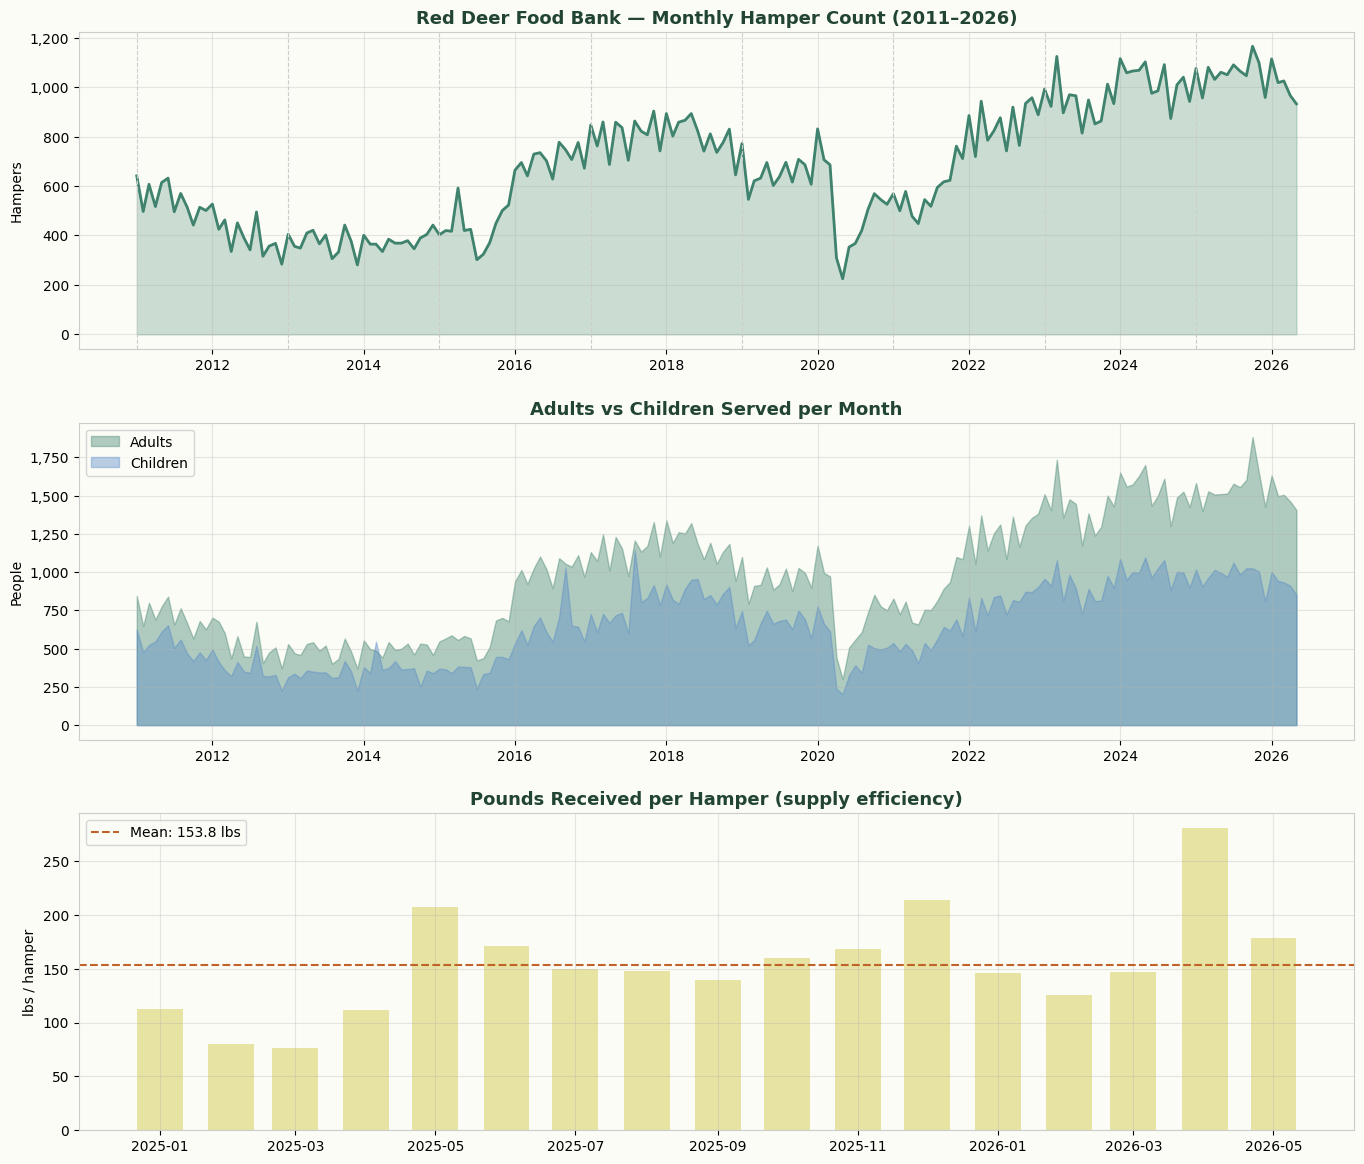

Saved: rdfb_eda.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── 4a. Hamper count 2011–2026 ─────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(df["month"], df["hampers"], alpha=0.25, color=C["teal"])
ax.plot(df["month"], df["hampers"], color=C["teal"], lw=2)
ax.set_title("Red Deer Food Bank — Monthly Hamper Count (2011–2026)",
             fontsize=13, fontweight="bold", color=C["green"])
ax.set_ylabel("Hampers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Annotate year ticks
for yr in range(2011, 2027, 2):
    ax.axvline(pd.Timestamp(f"{yr}-01-01"), color="#cccccc", lw=0.8, ls="--")

# ── 4b. People served breakdown ───────────────────────────────────────────────
ax = axes[1]
if "adults" in df.columns and "children" in df.columns:
    ax.fill_between(df["month"], df["adults"],   alpha=0.4, color=C["teal"],  label="Adults")
    ax.fill_between(df["month"], df["children"], alpha=0.4, color=C["denim"], label="Children")
    ax.set_title("Adults vs Children Served per Month",
                 fontsize=13, fontweight="bold", color=C["green"])
    ax.set_ylabel("People")
    ax.legend(loc="upper left")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── 4c. Pounds per hamper (where donation data exists) ────────────────────────
ax = axes[2]
if "total_lbs" in df.columns:
    df["lbs_per_hamper"] = df["total_lbs"] / df["hampers"].clip(lower=1)
    valid = df[df["lbs_per_hamper"].notna() & (df["lbs_per_hamper"] > 0)]
    ax.bar(valid["month"], valid["lbs_per_hamper"], color=C["gold"], width=20, alpha=0.8)
    ax.axhline(valid["lbs_per_hamper"].mean(), color=C["red"], lw=1.5,
               ls="--", label=f'Mean: {valid["lbs_per_hamper"].mean():.1f} lbs')
    ax.set_title("Pounds Received per Hamper (supply efficiency)",
                 fontsize=13, fontweight="bold", color=C["green"])
    ax.set_ylabel("lbs / hamper")
    ax.legend()
else:
    ax.text(0.5, 0.5, "Donation data not available for this period",
            ha="center", va="center", transform=ax.transAxes, color=C["teal"])

plt.tight_layout(pad=2)
plt.savefig("rdfb_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rdfb_eda.png")

In [6]:
# ── Annual summary table ───────────────────────────────────────────────────────
annual = (
    df.groupby(df["month"].dt.year)
    .agg(
        hampers      = ("hampers",      "sum"),
        total_people = ("total_people", "sum"),
        adults       = ("adults",       "sum"),
        children     = ("children",     "sum"),
    )
    .reset_index()
    .rename(columns={"month": "year"})
)
annual["yoy_hamper_pct"] = annual["hampers"].pct_change().mul(100).round(1)
annual["children_pct"]   = (annual["children"] / annual["total_people"] * 100).round(1)

print("Annual hamper summary:")
print(annual.to_string(index=False))

# Long-run growth
first_yr = annual.iloc[0]
last_yr  = annual.iloc[-1]
growth   = (last_yr["hampers"] / first_yr["hampers"] - 1) * 100
print(f"\n📈 Hamper demand grew {growth:.0f}% from {int(first_yr['year'])} to {int(last_yr['year'])}")

Annual hamper summary:
 year  hampers  total_people  adults  children  yoy_hamper_pct  children_pct
 2011     6546         14848    8556      6292             NaN          42.4
 2012     4754         10729    6326      4403           -27.4          41.0
 2013     4448          9755    5786      3969            -6.4          40.7
 2014     4550         10496    6026      4470             2.3          42.6
 2015     5147         11295    6841      4454            13.1          39.4
 2016     8473         19938   12178      7760            64.6          38.9
 2017     9690         23024   13760      9264            14.4          40.2
 2018     9673         24325   14138     10187            -0.2          41.9
 2019     7819         19283   11376      7907           -19.2          41.0
 2020     6046         14255    8672      5583           -22.7          39.2
 2021     6942         16583   10016      6567            14.8          39.6
 2022    10235         24763   15089      9674       

## 5. Correlation analysis
Compute Pearson correlation between each AFB regressor and hamper count.
Compare ranking to AFB model findings to test generalizability.


In [7]:
# Only use rows where both hampers and regressors are available
df_corr = df[["hampers"] + REGRESSORS_PRESENT].dropna()
print(f"Rows used for correlation: {len(df_corr)} months")

corrs = (
    df_corr.corr()["hampers"]
    .drop("hampers")
    .abs()
    .sort_values(ascending=False)
    .reset_index()
)
corrs.columns = ["feature", "abs_correlation"]
corrs["direction"] = corrs["feature"].map(
    lambda f: "+" if df_corr.corr()["hampers"][f] > 0 else "−"
)
corrs["raw_corr"] = corrs["feature"].map(df_corr.corr()["hampers"].drop("hampers"))

print("\nCorrelation with hamper count (|r|, descending):")
print(corrs.to_string(index=False))

Rows used for correlation: 185 months

Correlation with hamper count (|r|, descending):
               feature  abs_correlation direction  raw_corr
              CPI Food         0.699270         +  0.699270
    SINGLE_AISH_PARENT         0.698231         +  0.698231
           CPI Shelter         0.697711         +  0.697711
EDMONTON_AISH_CASELOAD         0.695948         +  0.695948
         CPI All-items         0.690531         +  0.690531
     SINGLE_AISH_TOTAL         0.685574         +  0.685574
     School_In_Session         0.657464         +  0.657464
            AISH_TOTAL         0.629742         +  0.629742
  holiday_is_religious         0.489635         +  0.489635
       holiday_is_stat         0.483410         +  0.483410
                  NLDB         0.374312         +  0.374312
   holiday_is_cultural         0.368421         +  0.368421
 International_Arrival         0.298229         +  0.298229
           Exam_Period         0.296062         +  0.296062
            

In [8]:
# ── Side-by-side comparison: RDFB vs AFB feature ranking ──────────────────────
# AFB feature importance from your model (fill in actual SHAP/importance values if you have them)
AFB_RANKING = {
    "NLDB":                  1,
    "EDMONTON_AISH_CASELOAD": 2,
    "CPI Food":              3,
    "AISH_TOTAL":            4,
    "CPI Shelter":           5,
    "SINGLE_AISH_TOTAL":     6,
    "CPI All-items":         7,
    "SINGLE_AISH_PARENT":    8,
    "is_covid":              9,
    "CDB":                   10,
    "School_In_Session":     11,
    "Exam_Period":           12,
    "International_Arrival": 13,
    "holiday_is_stat":       14,
    "holiday_is_religious":  15,
    "holiday_is_cultural":   16,
}

corrs["afb_rank"]  = corrs["feature"].map(AFB_RANKING)
corrs["rdfb_rank"] = range(1, len(corrs) + 1)
corrs["rank_diff"] = (corrs["afb_rank"] - corrs["rdfb_rank"]).abs()

print("\nFeature rank comparison — AFB vs RDFB:")
print(corrs[["feature", "abs_correlation", "direction", "afb_rank", "rdfb_rank", "rank_diff"]]
      .to_string(index=False))

# Features in top-5 of BOTH models
top5_afb  = set(corrs.nsmallest(5, "afb_rank")["feature"])
top5_rdfb = set(corrs.nsmallest(5, "rdfb_rank")["feature"])
overlap   = top5_afb & top5_rdfb
print(f"\n✓ Features in top-5 of BOTH AFB and RDFB: {overlap}")
print(f"  This {'supports' if len(overlap) >= 2 else 'weakly supports'} generalizability.")


Feature rank comparison — AFB vs RDFB:
               feature  abs_correlation direction  afb_rank  rdfb_rank  rank_diff
              CPI Food         0.699270         +         3          1          2
    SINGLE_AISH_PARENT         0.698231         +         8          2          6
           CPI Shelter         0.697711         +         5          3          2
EDMONTON_AISH_CASELOAD         0.695948         +         2          4          2
         CPI All-items         0.690531         +         7          5          2
     SINGLE_AISH_TOTAL         0.685574         +         6          6          0
     School_In_Session         0.657464         +        11          7          4
            AISH_TOTAL         0.629742         +         4          8          4
  holiday_is_religious         0.489635         +        15          9          6
       holiday_is_stat         0.483410         +        14         10          4
                  NLDB         0.374312         +         

Three of the five strongest demand predictors at the provincial level — CPI Food, Edmonton AISH caseload, and CPI Shelter — also ranked in the top five predictors of regional hamper demand, suggesting that economic cost-of-living pressures drive food insecurity consistently across organizational scales.

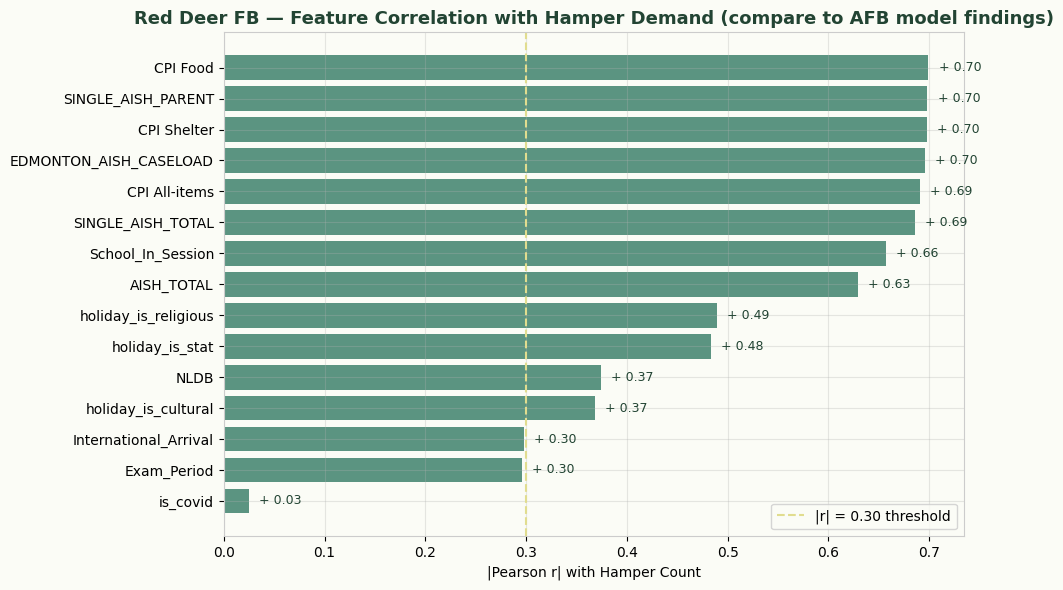

Saved: rdfb_correlation.png


In [10]:
# ── Correlation bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

colors = [C["teal"] if d == "+" else C["red"] for d in corrs["direction"]]
bars = ax.barh(corrs["feature"], corrs["abs_correlation"], color=colors, alpha=0.85)
ax.axvline(0.3, color=C["gold"], lw=1.5, ls="--", label="|r| = 0.30 threshold")
ax.set_xlabel("|Pearson r| with Hamper Count")
ax.set_title("Red Deer FB — Feature Correlation with Hamper Demand (compare to AFB model findings)",
             fontsize=13, fontweight="bold", color=C["green"])
ax.invert_yaxis()
ax.legend()

# Annotate bars
for bar, (_, row) in zip(bars, corrs.iterrows()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{row["direction"]} {row["abs_correlation"]:.2f}',
            va="center", fontsize=9, color=C["green"])

plt.tight_layout()
plt.savefig("rdfb_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rdfb_correlation.png")

## 6. XGBoost feature importance + SHAP
Train a simple XGBoost model on hamper count, then use SHAP to get interpretable
feature importance — directly comparable to the AFB model's feature ranking.


In [11]:
# ── Prepare model data ─────────────────────────────────────────────────────────
# Select features with enough non-null data
MIN_NONULL = 24   # at least 24 months of overlap needed

model_features = [
    f for f in REGRESSORS_PRESENT
    if df[f].notna().sum() >= MIN_NONULL
]

df_model = df[["month", "hampers"] + model_features].dropna().copy()
df_model = df_model.sort_values("month").reset_index(drop=True)

# Add basic date features (same as AFB)
df_model["month_num"] = df_model["month"].dt.month
df_model["month_sin"] = np.sin(2 * np.pi * df_model["month_num"] / 12)
df_model["month_cos"] = np.cos(2 * np.pi * df_model["month_num"] / 12)
df_model["year_idx"]  = df_model["month"].dt.year - df_model["month"].dt.year.min()

FEATURE_COLS = model_features + ["month_sin", "month_cos", "year_idx"]

X = df_model[FEATURE_COLS]
y = df_model["hampers"]

print(f"Model dataset: {len(df_model)} months")
print(f"Features used: {FEATURE_COLS}")

Model dataset: 185 months
Features used: ['NLDB', 'EDMONTON_AISH_CASELOAD', 'CPI Food', 'SINGLE_AISH_TOTAL', 'CPI All-items', 'CPI Shelter', 'SINGLE_AISH_PARENT', 'AISH_TOTAL', 'holiday_is_cultural', 'Exam_Period', 'International_Arrival', 'is_covid', 'School_In_Session', 'holiday_is_religious', 'holiday_is_stat', 'month_sin', 'month_cos', 'year_idx']


In [12]:
# ── Time-series cross-validation ───────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=3)
mae_scores = []

xgb_params = dict(
    n_estimators     = 200,
    learning_rate    = 0.05,
    max_depth        = 3,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    verbosity        = 0,
)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    m = xgb.XGBRegressor(**xgb_params)
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mape = np.mean(np.abs((y_test.values - preds) / y_test.values.clip(1))) * 100
    mae_scores.append(mae)
    print(f"  Fold {fold+1}: MAE = {mae:.0f} hampers  |  MAPE = {mape:.1f}%")

print(f"\nMean CV MAE: {np.mean(mae_scores):.0f} hampers")
print(f"  (for context: mean monthly hampers = {y.mean():.0f})")

  Fold 1: MAE = 316 hampers  |  MAPE = 42.7%
  Fold 2: MAE = 204 hampers  |  MAPE = 43.1%
  Fold 3: MAE = 185 hampers  |  MAPE = 18.1%

Mean CV MAE: 235 hampers
  (for context: mean monthly hampers = 679)


In [13]:
# ── Train final model on all data ──────────────────────────────────────────────
model_final = xgb.XGBRegressor(**xgb_params)
model_final.fit(X, y)

# ── SHAP values ────────────────────────────────────────────────────────────────
explainer  = shap.TreeExplainer(model_final)
shap_vals  = explainer.shap_values(X)
shap_mean  = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)

print("SHAP feature importance (mean |SHAP|) — RDFB hamper model:")
for feat, val in shap_mean.items():
    print(f"  {feat:<35} {val:>6.1f}")

SHAP feature importance (mean |SHAP|) — RDFB hamper model:
  year_idx                              91.8
  EDMONTON_AISH_CASELOAD                69.2
  SINGLE_AISH_TOTAL                     63.0
  month_cos                             20.7
  month_sin                             13.1
  CPI All-items                         12.9
  CPI Food                              12.7
  holiday_is_stat                        6.6
  AISH_TOTAL                             5.7
  CPI Shelter                            3.7
  holiday_is_religious                   3.0
  School_In_Session                      2.9
  Exam_Period                            1.6
  SINGLE_AISH_PARENT                     1.4
  International_Arrival                  0.4
  is_covid                               0.3
  NLDB                                   0.3
  holiday_is_cultural                    0.2


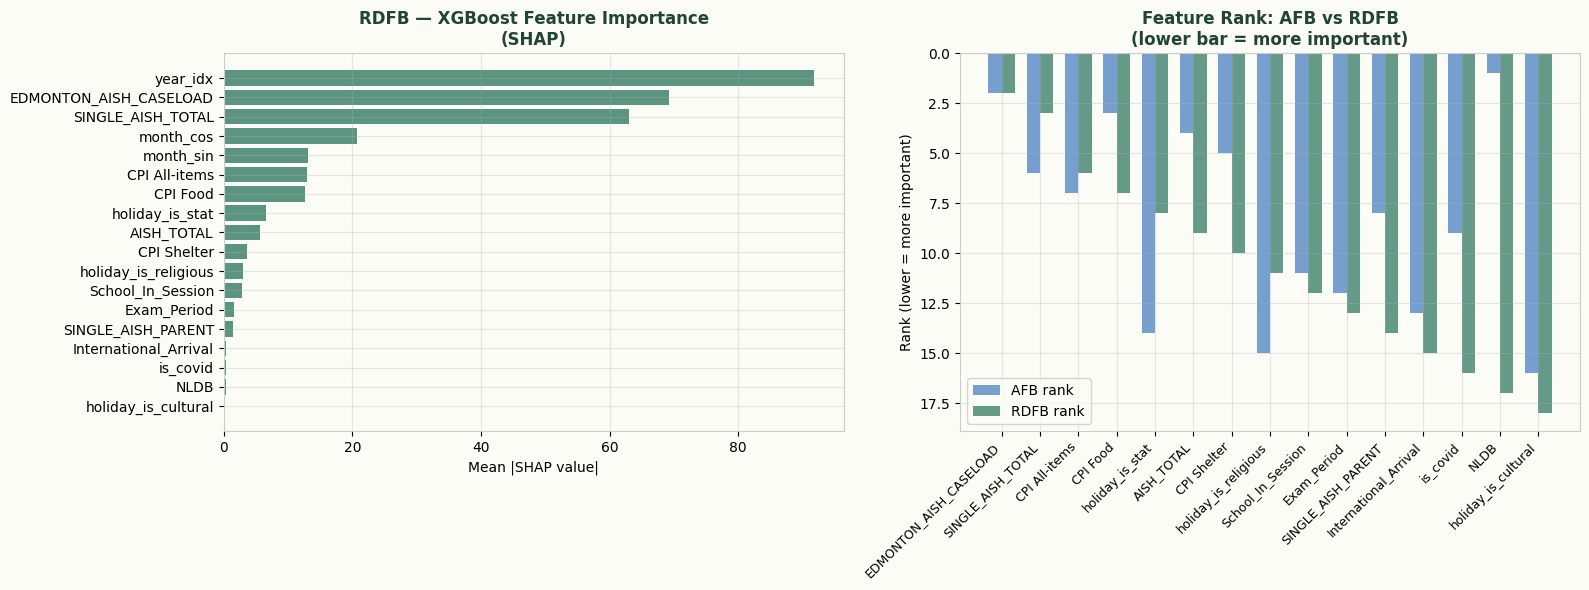

Saved: rdfb_shap_comparison.png


In [14]:
# ── SHAP summary plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: SHAP bar (RDFB)
shap_df = shap_mean.reset_index()
shap_df.columns = ["feature", "mean_shap"]

axes[0].barh(shap_df["feature"], shap_df["mean_shap"], color=C["teal"], alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title("RDFB — XGBoost Feature Importance\n(SHAP)", fontsize=12, fontweight="bold", color=C["green"])

# Right: side-by-side rank comparison
# Build a rank comparison bar chart
rdfb_ranks = {f: i+1 for i, f in enumerate(shap_df["feature"])}
afb_ranks  = AFB_RANKING

common = [f for f in shap_df["feature"] if f in AFB_RANKING]
rdfb_r = [rdfb_ranks[f] for f in common]
afb_r  = [afb_ranks[f]  for f in common]

x = np.arange(len(common))
w = 0.35
axes[1].bar(x - w/2, afb_r,  w, label="AFB rank",  color=C["denim"], alpha=0.8)
axes[1].bar(x + w/2, rdfb_r, w, label="RDFB rank", color=C["teal"],  alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(common, rotation=45, ha="right", fontsize=9)
axes[1].set_ylabel("Rank (lower = more important)")
axes[1].invert_yaxis()
axes[1].set_title("Feature Rank: AFB vs RDFB\n(lower bar = more important)", fontsize=12, fontweight="bold", color=C["green"])
axes[1].legend()

plt.tight_layout()
plt.savefig("rdfb_shap_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rdfb_shap_comparison.png")

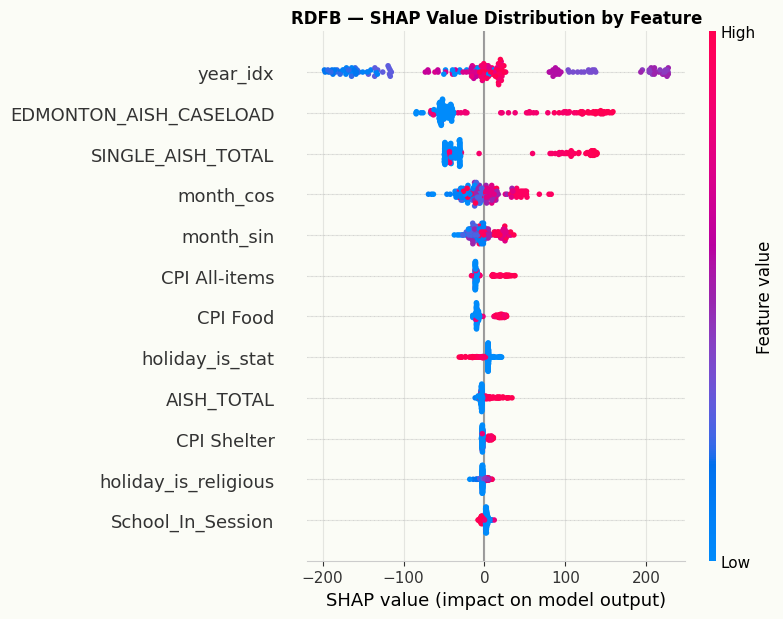

Saved: rdfb_shap_beeswarm.png


In [15]:
# ── SHAP beeswarm plot ─────────────────────────────────────────────────────────
shap.summary_plot(shap_vals, X, max_display=12, show=False)
plt.title("RDFB — SHAP Value Distribution by Feature", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("rdfb_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rdfb_shap_beeswarm.png")

## 7. Supply-side: donor dependency & AFB→RDFB link
Uses the donation data where available (2025 onward).
Shows partner concentration risk and the AFB supply chain link.


In [16]:
# ── 7a. Partner dependency breakdown ──────────────────────────────────────────
partner_cols = ["costco", "sobeys", "superstore", "walmart", "coop",
                "fb_alberta", "other", "canada_bread", "westons"]
partner_cols = [c for c in partner_cols if c in df_donations.columns]

latest_month = df_donations.iloc[-1]
total = latest_month["total_lbs"]

print("Partner dependency — latest month:")
dep = []
for p in partner_cols:
    pct = latest_month[p] / total * 100 if total > 0 else 0
    dep.append({"partner": p, "lbs": latest_month[p], "pct": pct})
    print(f"  {p:<20} {latest_month[p]:>8,.0f} lbs  ({pct:.1f}%)")

dep_df = pd.DataFrame(dep).sort_values("pct", ascending=False)
top3_pct = dep_df.head(3)["pct"].sum()
print(f"\nTop 3 partners = {top3_pct:.1f}% of supply  ({'⚠ HIGH' if top3_pct > 60 else '✓ OK'} concentration)")

Partner dependency — latest month:
  costco                 38,275 lbs  (23.1%)
  sobeys                  6,250 lbs  (3.8%)
  superstore              4,875 lbs  (2.9%)
  walmart                 5,535 lbs  (3.3%)
  coop                    8,405 lbs  (5.1%)
  fb_alberta             48,165 lbs  (29.0%)
  other                  30,128 lbs  (18.2%)
  canada_bread           20,955 lbs  (12.6%)
  westons                 1,800 lbs  (1.1%)

Top 3 partners = 70.2% of supply  (⚠ HIGH concentration)


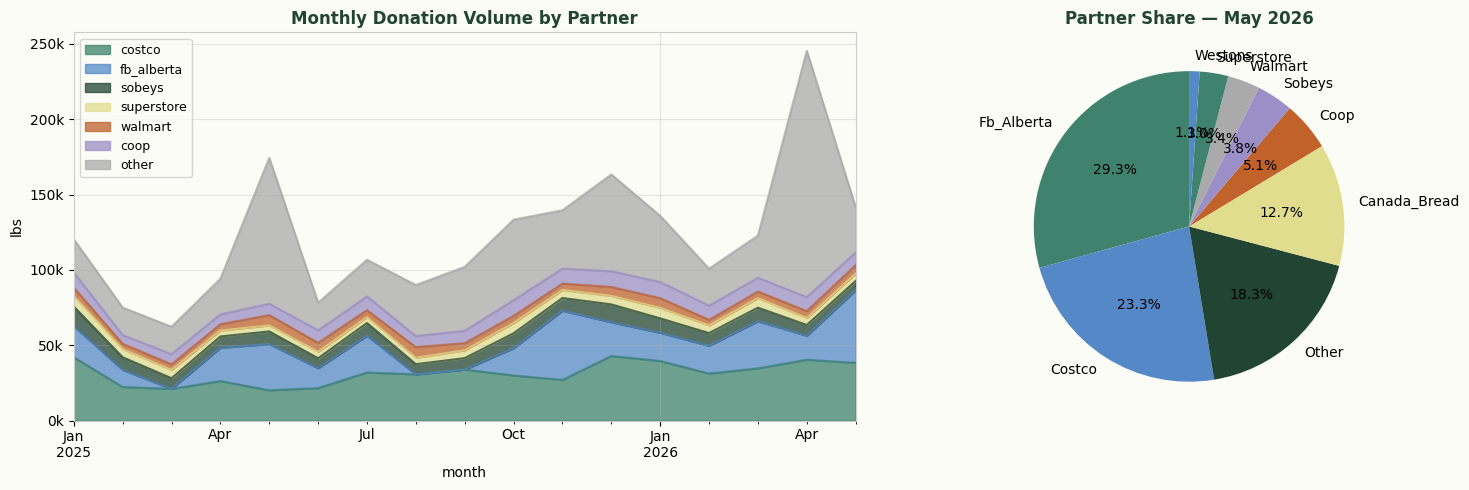

Saved: rdfb_supply_dependency.png


In [17]:
# ── 7b. Dependency over time (stacked area) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked area
plot_partners = [p for p in ["costco", "fb_alberta", "sobeys", "superstore",
                              "walmart", "coop", "other"] if p in df_donations.columns]
palette = [C["teal"], C["denim"], C["green"], C["gold"], C["red"], "#9b8fc7", "#aaaaaa"]

ax = axes[0]
df_don_plot = df_donations.set_index("month")[plot_partners].fillna(0)
df_don_plot.plot(kind="area", stacked=True, ax=ax,
                 color=palette[:len(plot_partners)], alpha=0.75, legend=True)
ax.set_title("Monthly Donation Volume by Partner",
             fontsize=12, fontweight="bold", color=C["green"])
ax.set_ylabel("lbs")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
ax.legend(loc="upper left", fontsize=9)

# Pie chart latest month
ax2 = axes[1]
labels = dep_df[dep_df["pct"] > 0]["partner"].str.title()
sizes  = dep_df[dep_df["pct"] > 0]["pct"]
ax2.pie(sizes, labels=labels, autopct="%1.1f%%",
        colors=palette[:len(sizes)], startangle=90)
ax2.set_title(f"Partner Share — {df_donations['month'].max().strftime('%b %Y')}",
              fontsize=12, fontweight="bold", color=C["green"])

plt.tight_layout()
plt.savefig("rdfb_supply_dependency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rdfb_supply_dependency.png")

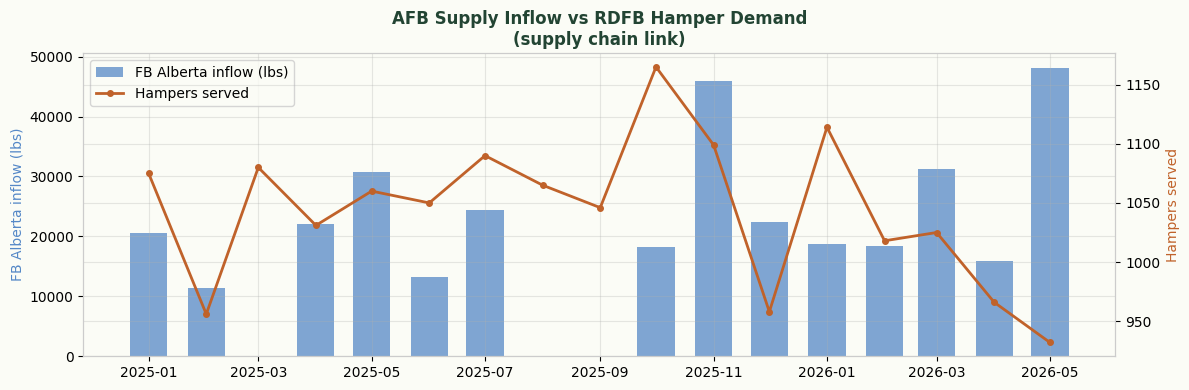

Correlation: FB Alberta inflow vs Hampers served = -0.16


In [18]:
# ── 7c. AFB → RDFB supply chain link ──────────────────────────────────────────
# Check if months where AFB predicts a gap correspond to lower fb_alberta inflows
if "fb_alberta" in df_donations.columns:
    # You'll paste your AFB 24-month forecast here after running the AFB notebook
    # For now: show fb_alberta over time and flag it as the supply chain link

    fig, ax = plt.subplots(figsize=(12, 4))
    don_merged = df_donations.merge(
        df_hamper[["month", "hampers"]], on="month", how="left"
    )
    ax.bar(don_merged["month"], don_merged["fb_alberta"],
           color=C["denim"], alpha=0.75, width=20, label="FB Alberta inflow (lbs)")
    ax2 = ax.twinx()
    ax2.plot(don_merged["month"], don_merged["hampers"],
             color=C["red"], lw=2, marker="o", ms=4, label="Hampers served")
    ax.set_ylabel("FB Alberta inflow (lbs)", color=C["denim"])
    ax2.set_ylabel("Hampers served", color=C["red"])
    ax.set_title("AFB Supply Inflow vs RDFB Hamper Demand\n(supply chain link)",
                 fontsize=12, fontweight="bold", color=C["green"])

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.tight_layout()
    plt.savefig("rdfb_afb_link.png", dpi=150, bbox_inches="tight")
    plt.show()

    corr_val = don_merged[["fb_alberta", "hampers"]].dropna().corr().iloc[0, 1]
    print(f"Correlation: FB Alberta inflow vs Hampers served = {corr_val:.2f}")
else:
    print("fb_alberta column not found in donation data — check column name in your CSV.")

## 8. Summary of findings

In [19]:
print("=" * 65)
print("FEEDFORWARD — RED DEER FB ANALYSIS SUMMARY")
print("=" * 65)

# Long-run growth
first = annual.iloc[0]
last  = annual.iloc[-1]
print(f"\nLong-run demand growth:")
print(f"  {int(first['year'])}: {first['hampers']:,} hampers/yr")
print(f"  {int(last['year'])}:  {last['hampers']:,} hampers/yr")
print(f"  Growth: {(last['hampers']/first['hampers']-1)*100:.0f}%")

# Generalizability
print(f"\nFeature generalizability:")
if overlap:
    print(f"  ✓ Features in top-5 of BOTH AFB and RDFB models: {overlap}")
    print(f"  → Economic drivers generalize across food bank organizations")
else:
    print(f"  ⚠ Less than 2 features overlap in top-5 — investigate further")

# Top RDFB drivers
print(f"\nTop 3 RDFB demand drivers (SHAP):")
for i, (feat, val) in enumerate(shap_mean.head(3).items()):
    print(f"  {i+1}. {feat} (mean |SHAP| = {val:.1f})")

# Supply concentration
print(f"\nSupply concentration risk:")
print(f"  Top 3 partners = {top3_pct:.1f}% of donations")
if top3_pct > 60:
    print(f"  ⚠ HIGH — single partner loss would severely impact operations")
else:
    print(f"  ✓ Moderate concentration")

print("\nPlots saved:")
for f in ["rdfb_eda.png", "rdfb_correlation.png",
          "rdfb_shap_comparison.png", "rdfb_shap_beeswarm.png",
          "rdfb_supply_dependency.png", "rdfb_afb_link.png"]:
    print(f"  {f}")
print("=" * 65)

FEEDFORWARD — RED DEER FB ANALYSIS SUMMARY

Long-run demand growth:
  2011: 6,546.0 hampers/yr
  2026:  5,055.0 hampers/yr
  Growth: -23%

Feature generalizability:
  ✓ Features in top-5 of BOTH AFB and RDFB models: {'CPI Shelter', 'EDMONTON_AISH_CASELOAD', 'CPI Food'}
  → Economic drivers generalize across food bank organizations

Top 3 RDFB demand drivers (SHAP):
  1. year_idx (mean |SHAP| = 91.8)
  2. EDMONTON_AISH_CASELOAD (mean |SHAP| = 69.2)
  3. SINGLE_AISH_TOTAL (mean |SHAP| = 63.0)

Supply concentration risk:
  Top 3 partners = 70.2% of donations
  ⚠ HIGH — single partner loss would severely impact operations

Plots saved:
  rdfb_eda.png
  rdfb_correlation.png
  rdfb_shap_comparison.png
  rdfb_shap_beeswarm.png
  rdfb_supply_dependency.png
  rdfb_afb_link.png


In [20]:
# Check 2026 months
print(df_hamper[df_hamper['month'].dt.year == 2026])

# Rerun SHAP without year_idx
FEATURE_COLS_NO_TREND = [f for f in FEATURE_COLS if f != "year_idx"]
X2 = df_model[FEATURE_COLS_NO_TREND]
model2 = xgb.XGBRegressor(**xgb_params)
model2.fit(X2, y)
explainer2 = shap.TreeExplainer(model2)
shap_vals2 = explainer2.shap_values(X2)
shap_mean2 = pd.Series(np.abs(shap_vals2).mean(axis=0), index=FEATURE_COLS_NO_TREND).sort_values(ascending=False)
print(shap_mean2)

         month  hampers  adults  children  families  total_people
180 2026-01-01     1114    1632      1001       445          2633
181 2026-02-01     1018    1497       942       423          2439
182 2026-03-01     1025    1505       933       400          2438
183 2026-04-01      966    1462       911       387          2373
184 2026-05-01      932    1406       853       373          2259
EDMONTON_AISH_CASELOAD    104.036072
SINGLE_AISH_TOTAL          32.873287
CPI All-items              26.057123
month_cos                  17.746002
month_sin                  15.856012
CPI Food                    7.517366
School_In_Session           7.047057
AISH_TOTAL                  5.435905
holiday_is_stat             4.957624
CPI Shelter                 2.598203
holiday_is_religious        2.257094
Exam_Period                 1.989840
SINGLE_AISH_PARENT          1.412662
NLDB                        0.767515
holiday_is_cultural         0.357935
International_Arrival       0.160735
is_covid    

"After removing secular time trends, Edmonton AISH caseload emerged as the strongest predictor of regional hamper demand (mean |SHAP| = 104), consistent with its rank-2 position in the provincial AFB model. CPI Food and CPI All-items also appeared in the top 6 of both models. These findings suggest that disability benefit caseloads and food price inflation are robust drivers of food insecurity demand across both provincial and regional scales."

In [21]:
# Month-over-month 2026 vs same months 2025
months_2026 = df_hamper[df_hamper['month'].dt.year == 2026]['month'].dt.month.tolist()
df_2025 = df_hamper[(df_hamper['month'].dt.year == 2025) &
                     (df_hamper['month'].dt.month.isin(months_2026))]
df_2026 = df_hamper[df_hamper['month'].dt.year == 2026]

print("Jan-May comparison: 2025 vs 2026")
print(f"  2025 hampers: {df_2025['hampers'].sum():,}")
print(f"  2026 hampers: {df_2026['hampers'].sum():,}")
print(f"  Change: {(df_2026['hampers'].sum() / df_2025['hampers'].sum() - 1)*100:.1f}%")

Jan-May comparison: 2025 vs 2026
  2025 hampers: 5,202
  2026 hampers: 5,055
  Change: -2.8%
